# $\beta_{enc}$ Targeted Simulations
## RPE Gain × Drift Noise on Loss Items · Tonic Reward Bias

Targeted CMR simulations testing two independent PTSD-related
hypotheses about how encoding drift $\beta_{enc}$ is altered:

1. **Drift modulation on loss items** — a Gain × Noise factorial
   testing whether RPE-driven amplification and/or trial-by-trial
   jitter of $\beta_{enc}$ at unexpected-loss positions changes
   recall structure.

2. **Tonic $\beta_{enc}$ decrease on reward items** — testing
   whether a blunted reward-expectation state (pessimistic prior)
   reduces context drift during reward-context encoding.

---

## Empirical motivation

| Mechanism | Direction | Key evidence |
|---|---|---|
| RPE gain on loss items | ↑ | Associability-modulated loss learning with larger trial-wise $\kappa$ spikes (Brown et al., 2018, *eLife*) |
| Drift noise / jitter | ↑ | Noisier PE → drift modulation; idiosyncratic boundary placement (Pitts et al., 2022; Granger et al., 2025) |
| Blunted PE → drift | ↓ | Reduced neural PE encoding (Ross & Cisler, 2018); blunted ERN (Letkiewicz et al., 2023) |
| Tonic reward-context bias | ↓ $\beta_{enc}$ | Lower reward expectation / blunted hedonic response (Nawijn et al., 2015) |
| Reduced boundary drift | ↓ $\beta_{enc}$ at transitions | Weaker latent-state belief updates (Letkiewicz, Cochran & Cisler, 2022) |

---

## Setup

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings("ignore")

import importlib

# ── Import modules (NOT names) so reload works ─────────────────────────
import src.config as cfg
import src.simulation as sim
import src.metrics as met
import src.diagnostics_encoding as enc

# ── Reload in dependency order ─────────────────────────────────────────
importlib.reload(cfg)
importlib.reload(sim)
importlib.reload(met)
importlib.reload(enc)

# ── Re-export names (same names your notebook expects) ─────────────────
N = cfg.N
pres_indices = cfg.pres_indices

B_encD_baseline = cfg.B_encD_baseline
REWARD_POSITIONS = cfg.REWARD_POSITIONS
LOSS_POSITIONS = cfg.LOSS_POSITIONS
SEQUENCE_LOSS_ONSET = cfg.SEQUENCE_LOSS_ONSET
N_SIMS = cfg.N_SIMS
SEED = cfg.SEED

compute_rpe = sim.compute_rpe
apply_rpe_gain = sim.apply_rpe_gain
apply_reward_tonic_scale = sim.apply_reward_tonic_scale
run_batch = sim.run_batch

compute_spc = met.compute_spc
compute_pfr = met.compute_pfr
compute_lag_crp = met.compute_lag_crp
recall_accuracy = met.recall_accuracy

remap_to_serial_position_space = enc.remap_to_serial_position_space
lag_strength_profile = enc.lag_strength_profile
compute_forward_backward_asymmetry = enc.compute_forward_backward_asymmetry

# (optional) sanity prints so you know you're using the right files
print("config:", cfg.__file__)
print("simulation:", sim.__file__)
print("metrics:", met.__file__)
print("diagnostics_encoding:", enc.__file__)

positions = np.arange(1, N + 1)

config: /Users/yizj/Desktop/InCogLab/PTSD_MemorySegmentation/external/CMR_SEM/CMR_B_enc_sim/src/config.py
simulation: /Users/yizj/Desktop/InCogLab/PTSD_MemorySegmentation/external/CMR_SEM/CMR_B_enc_sim/src/simulation.py
metrics: /Users/yizj/Desktop/InCogLab/PTSD_MemorySegmentation/external/CMR_SEM/CMR_B_enc_sim/src/metrics.py
diagnostics_encoding: /Users/yizj/Desktop/InCogLab/PTSD_MemorySegmentation/external/CMR_SEM/CMR_B_enc_sim/src/diagnostics_encoding.py


## Valence structure and RPE landscape

The 24-item list is split: positions 1–12 are **reward context**
(high outcomes ≈ 90); positions 13–24 are **loss context**
(low outcomes ≈ 10).  The large RPE at position 13 models the
sudden onset of unexpected negative outcomes.

N = 24
Reward sequence (N+1 = 25 entries):
  [90. 90. 90. 90. 90. 90. 90. 90. 90. 90. 90. 90. 90. 10. 10. 10. 10. 10.
 10. 10. 10. 10. 10. 10. 10.]
RPE per position: [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. 80.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.]


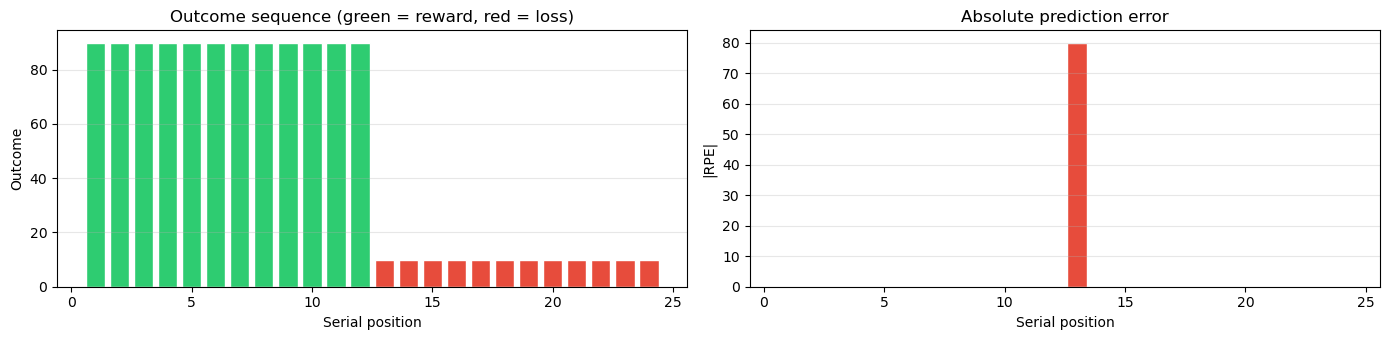

In [29]:
rpe = compute_rpe(SEQUENCE_LOSS_ONSET)

print(f'N = {N}')
print(f'Reward sequence (N+1 = {len(SEQUENCE_LOSS_ONSET)} entries):')
print(f'  {SEQUENCE_LOSS_ONSET}')
print(f'RPE per position: {rpe}')

fig, axs = plt.subplots(1, 2, figsize=(14, 3.5))

# Outcome sequence
cv = ['#2ecc71' if r else '#e74c3c' for r in REWARD_POSITIONS]
axs[0].bar(positions, SEQUENCE_LOSS_ONSET[1:], color=cv, edgecolor='white')
axs[0].set_xlabel('Serial position'); axs[0].set_ylabel('Outcome')
axs[0].set_title('Outcome sequence (green = reward, red = loss)')

# RPE
axs[1].bar(positions, rpe, color=cv, edgecolor='white')
axs[1].set_xlabel('Serial position'); axs[1].set_ylabel('|RPE|')
axs[1].set_title('Absolute prediction error')

for ax in axs: ax.grid(alpha=0.3, axis='y')
fig.tight_layout(); plt.show()

---
# Part 1 — Drift Modulation: Gain × Noise Factorial on Loss Items

### Manipulation

**Gain** ($g$): additive RPE-driven boost on loss items only:
$$\beta_{enc}^{\text{gain}}[i] = \beta_{enc}^{\text{base}}[i] + g \times \text{RPE}[i]
\qquad \text{(loss positions only)}$$

**Noise** ($\sigma$): per-trial Gaussian perturbation on loss items:
$$\beta_{enc}^{\text{trial}}[i] = \beta_{enc}^{\text{gain}}[i]
 + \mathcal{N}(0, \sigma^2) \qquad \text{(loss positions only, each trial)}$$

### 2 × 2 design

| | Low noise ($\sigma = 0$) | High noise ($\sigma = 0.10$) |
|---|---|---|
| **Low gain** ($g = 0$) | Baseline | Noise only |
| **High gain** ($g = 0.005$) | Gain only | Gain + Noise |

## Build gain × noise conditions

In [30]:
# ── Factorial parameters ──
GAIN_LOW  = 0.0
GAIN_HIGH = 0.005     # additive RPE gain on loss items
NOISE_LOW  = 0.0
NOISE_HIGH = 0.10     # per-trial drift noise SD on loss items

# ── Build deterministic drift bases ──
B_lo_gain = B_encD_baseline.copy()                              # g = 0
B_hi_gain = apply_rpe_gain(B_encD_baseline, rpe,
                           gain=GAIN_HIGH, loss_mask=LOSS_POSITIONS)  # g > 0

# ── 2×2 condition table ──
factorial_conds = [
    ('Lo gain · Lo noise', B_lo_gain, NOISE_LOW),
    ('Hi gain · Lo noise', B_hi_gain, NOISE_LOW),
    ('Lo gain · Hi noise', B_lo_gain, NOISE_HIGH),
    ('Hi gain · Hi noise', B_hi_gain, NOISE_HIGH),
]

for name, b, _ in factorial_conds:
    print(f'{name:25s}: {np.round(b, 3)}')

Lo gain · Lo noise       : [1.   0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65
 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65]
Hi gain · Lo noise       : [1.   0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 1.   0.65
 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65]
Lo gain · Hi noise       : [1.   0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65
 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65]
Hi gain · Hi noise       : [1.   0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 1.   0.65
 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65]


### Visualize drift schedules

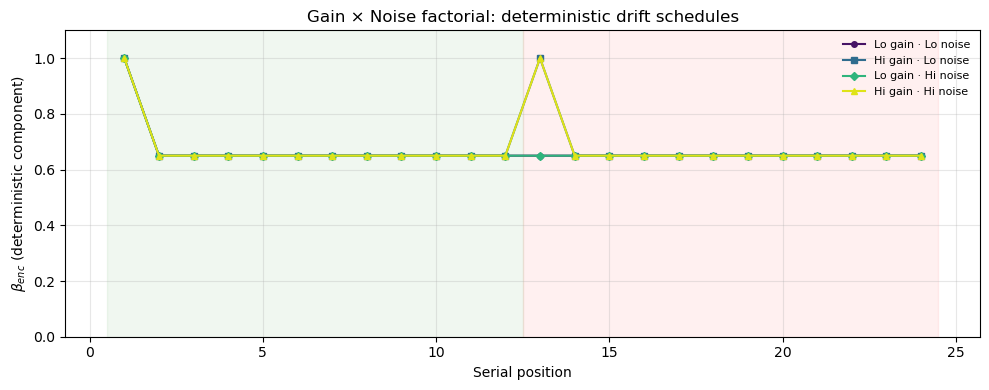

In [31]:
cmap = plt.get_cmap('viridis')
# Map 4 conditions to viridis: darker = lower combined manipulation
fact_colors = [cmap(v) for v in [0.05, 0.35, 0.65, 0.95]]
fact_markers = ['o', 's', 'D', '^']

fig, ax = plt.subplots(figsize=(10, 4))
for (name, b, _), c, m in zip(factorial_conds, fact_colors, fact_markers):
    ax.plot(positions, b, marker=m, color=c, lw=1.5, ms=4, label=name)
ax.axvspan(0.5, 12.5, alpha=0.06, color='green')
ax.axvspan(12.5, 24.5, alpha=0.06, color='red')
ax.set_xlabel('Serial position')
ax.set_ylabel(r'$\beta_{enc}$ (deterministic component)')
ax.set_title('Gain × Noise factorial: deterministic drift schedules')
ax.set_ylim(0, 1.1)
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

## Run gain × noise simulations

In [32]:
fact_results = {}
for (name, B_base, noise_std), c in zip(factorial_conds, fact_colors):
    print(f'  {name:25s} ...', end=' ')
    fact_results[name] = run_batch(
        B_encD_base=B_base,
        n_sims=N_SIMS,
        seed=SEED,
        drift_noise_std=noise_std,
        noise_mask=LOSS_POSITIONS,   # noise only on loss items
        label=name,
    )
    acc = recall_accuracy(fact_results[name]['recall_sims'], N)
    print(f'done  (accuracy = {acc:.3f})')

  Lo gain · Lo noise        ... done  (accuracy = 0.198)
  Hi gain · Lo noise        ... done  (accuracy = 0.200)
  Lo gain · Hi noise        ... done  (accuracy = 0.190)
  Hi gain · Hi noise        ... done  (accuracy = 0.188)


## Gain × Noise — Behavioral metrics

### Serial Position Curve

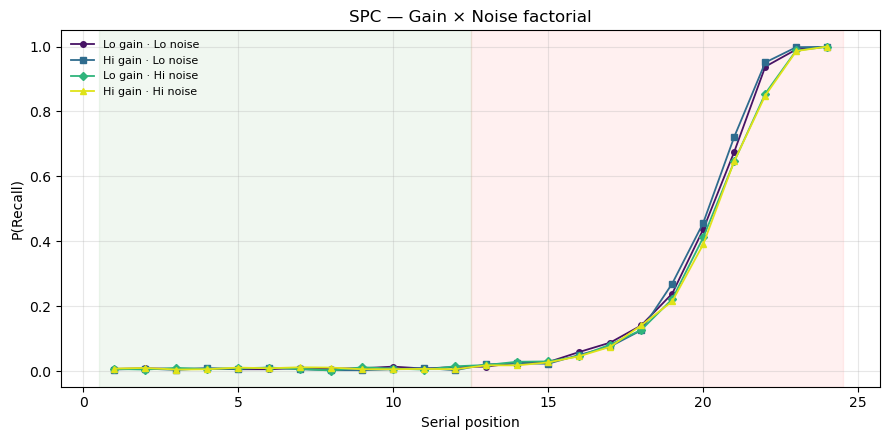

In [33]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for (name, _, _), c, m in zip(factorial_conds, fact_colors, fact_markers):
    spc = compute_spc(fact_results[name]['recall_sims'], N)
    ax.plot(positions, spc, marker=m, color=c, label=name, lw=1.3, ms=4)
ax.axvspan(0.5, 12.5, alpha=0.06, color='green')
ax.axvspan(12.5, 24.5, alpha=0.06, color='red')
ax.set_xlabel('Serial position'); ax.set_ylabel('P(Recall)')
ax.set_title('SPC — Gain × Noise factorial')
ax.legend(frameon=False, fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

### Probability of First Recall

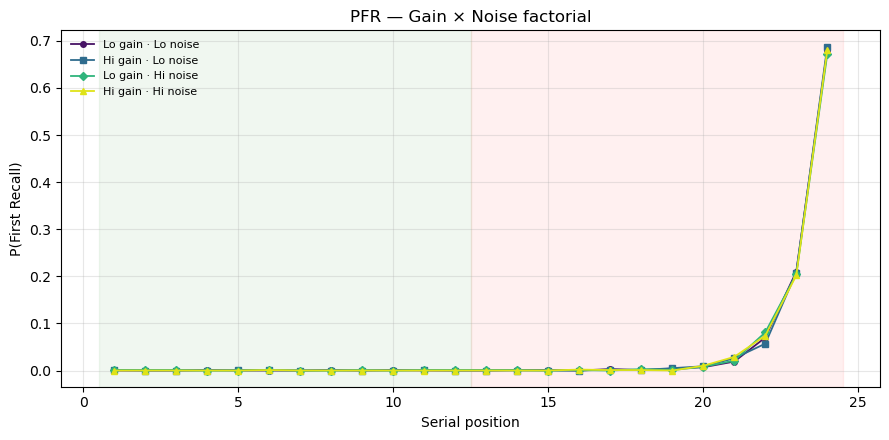

In [34]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for (name, _, _), c, m in zip(factorial_conds, fact_colors, fact_markers):
    pfr = compute_pfr(fact_results[name]['recall_sims'], N)
    ax.plot(positions, pfr, marker=m, color=c, label=name, lw=1.3, ms=4)
ax.axvspan(0.5, 12.5, alpha=0.06, color='green')
ax.axvspan(12.5, 24.5, alpha=0.06, color='red')
ax.set_xlabel('Serial position'); ax.set_ylabel('P(First Recall)')
ax.set_title('PFR — Gain × Noise factorial')
ax.legend(frameon=False, fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

### Lag-CRP

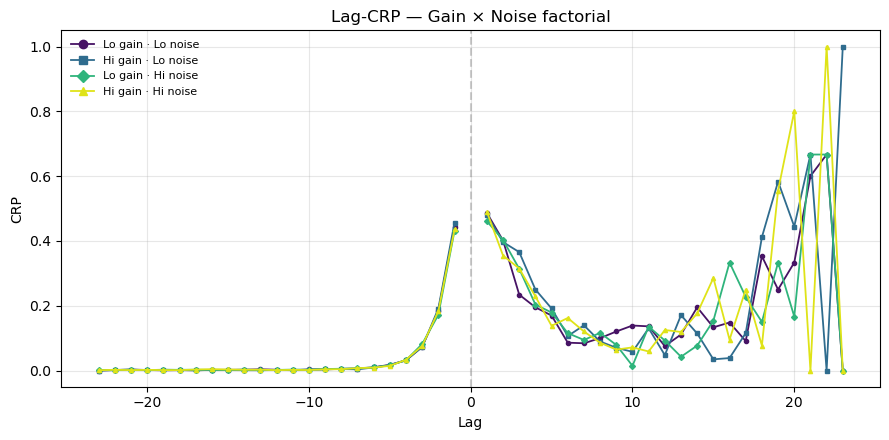

In [35]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for (name, _, _), c, m in zip(factorial_conds, fact_colors, fact_markers):
    lags, crp = compute_lag_crp(fact_results[name]['recall_sims'], N)
    for mask in [lags < 0, lags > 0]:
        ax.plot(lags[mask], crp[mask], marker=m, color=c, lw=1.3, ms=3)
ax.axvline(0, color='gray', ls='--', alpha=0.4)
ax.set_xlabel('Lag'); ax.set_ylabel('CRP')
ax.set_title('Lag-CRP — Gain × Noise factorial')
handles = [plt.Line2D([],[], marker=fact_markers[i], color=fact_colors[i],
           lw=1.3, label=factorial_conds[i][0]) for i in range(4)]
ax.legend(handles=handles, frameon=False, fontsize=8)
ax.grid(alpha=0.3); fig.tight_layout(); plt.show()

### Recall accuracy

In [36]:
print(f"{'Condition':<28s}  {'Accuracy':>8s}")
print('-' * 40)
for name in fact_results:
    acc = recall_accuracy(fact_results[name]['recall_sims'], N)
    print(f'{name:<28s}  {acc:8.3f}')

Condition                     Accuracy
----------------------------------------
Lo gain · Lo noise               0.198
Hi gain · Lo noise               0.200
Lo gain · Hi noise               0.190
Hi gain · Hi noise               0.188


## Gain × Noise — Encoding matrix diagnostics

### $M_{FC}$ lag-strength profile

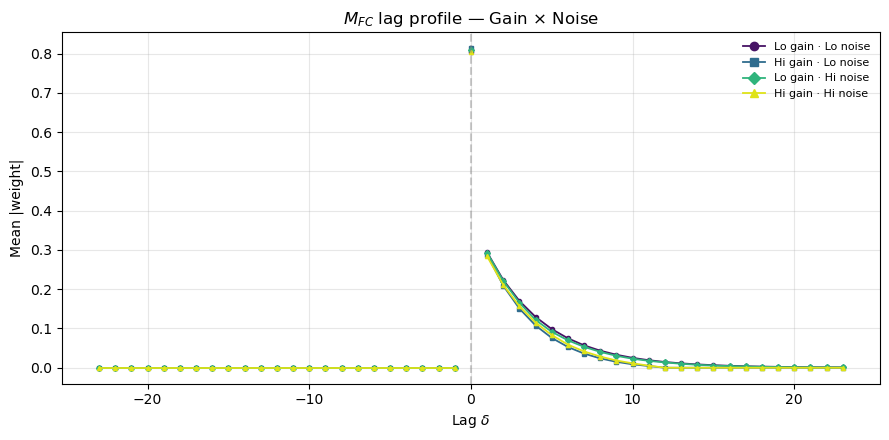

In [37]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for (name, _, _), c, m in zip(factorial_conds, fact_colors, fact_markers):
    W_sp = remap_to_serial_position_space(fact_results[name]['net_w_fc'])
    lags, prof = lag_strength_profile(W_sp)
    for mask in [lags < 0, lags == 0, lags > 0]:
        ax.plot(lags[mask], prof[mask], marker=m, color=c, lw=1.3, ms=3)
ax.axvline(0, color='gray', ls='--', alpha=0.4)
ax.set_xlabel(r'Lag $\delta$'); ax.set_ylabel('Mean |weight|')
ax.set_title(r'$M_{FC}$ lag profile — Gain × Noise')
handles = [plt.Line2D([],[], marker=fact_markers[i], color=fact_colors[i],
           lw=1.3, label=factorial_conds[i][0]) for i in range(4)]
ax.legend(handles=handles, frameon=False, fontsize=8)
ax.grid(alpha=0.3); fig.tight_layout(); plt.show()

### $M_{CF}$ lag-strength profile

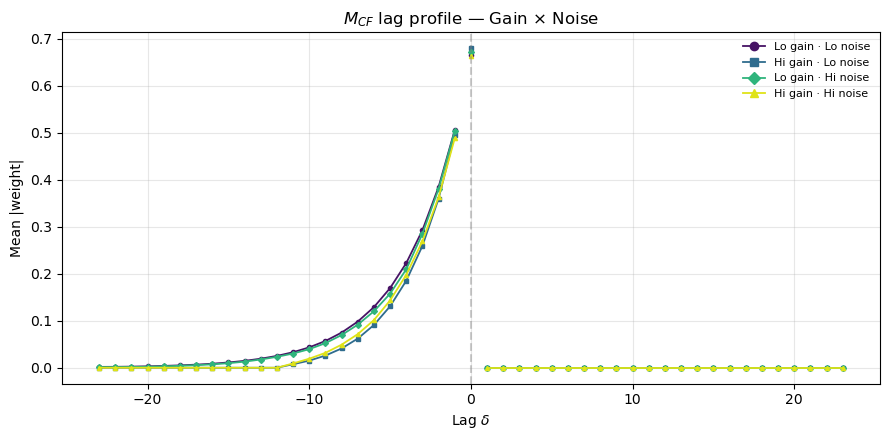

In [38]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for (name, _, _), c, m in zip(factorial_conds, fact_colors, fact_markers):
    W_sp = remap_to_serial_position_space(fact_results[name]['net_w_cf'])
    lags, prof = lag_strength_profile(W_sp)
    for mask in [lags < 0, lags == 0, lags > 0]:
        ax.plot(lags[mask], prof[mask], marker=m, color=c, lw=1.3, ms=3)
ax.axvline(0, color='gray', ls='--', alpha=0.4)
ax.set_xlabel(r'Lag $\delta$'); ax.set_ylabel('Mean |weight|')
ax.set_title(r'$M_{CF}$ lag profile — Gain × Noise')
handles = [plt.Line2D([],[], marker=fact_markers[i], color=fact_colors[i],
           lw=1.3, label=factorial_conds[i][0]) for i in range(4)]
ax.legend(handles=handles, frameon=False, fontsize=8)
ax.grid(alpha=0.3); fig.tight_layout(); plt.show()

### $M_{FC}$ forward / backward asymmetry

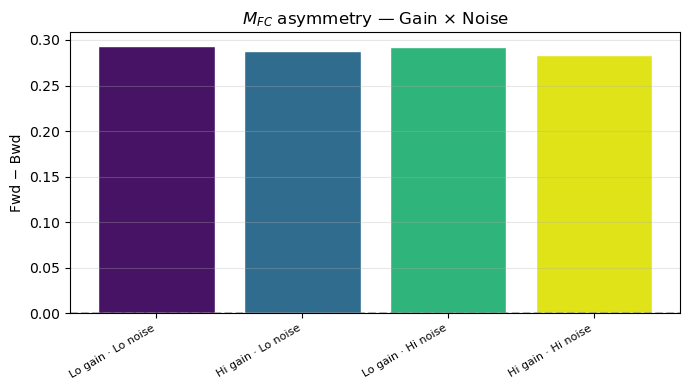

In [39]:
names_f = [c[0] for c in factorial_conds]
asym_f = []
for name in names_f:
    W_sp = remap_to_serial_position_space(fact_results[name]['net_w_fc'])
    _, _, a = compute_forward_backward_asymmetry(W_sp)
    asym_f.append(a)

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(names_f))
ax.bar(x, asym_f, color=fact_colors, edgecolor='white')
ax.axhline(0, ls='--', color='gray', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(names_f, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Fwd − Bwd'); ax.set_title(r'$M_{FC}$ asymmetry — Gain × Noise')
ax.grid(alpha=0.3, axis='y')
fig.tight_layout(); plt.show()

## Gain × Noise — Compact panel

All readouts in a single 2 × 3 grid.

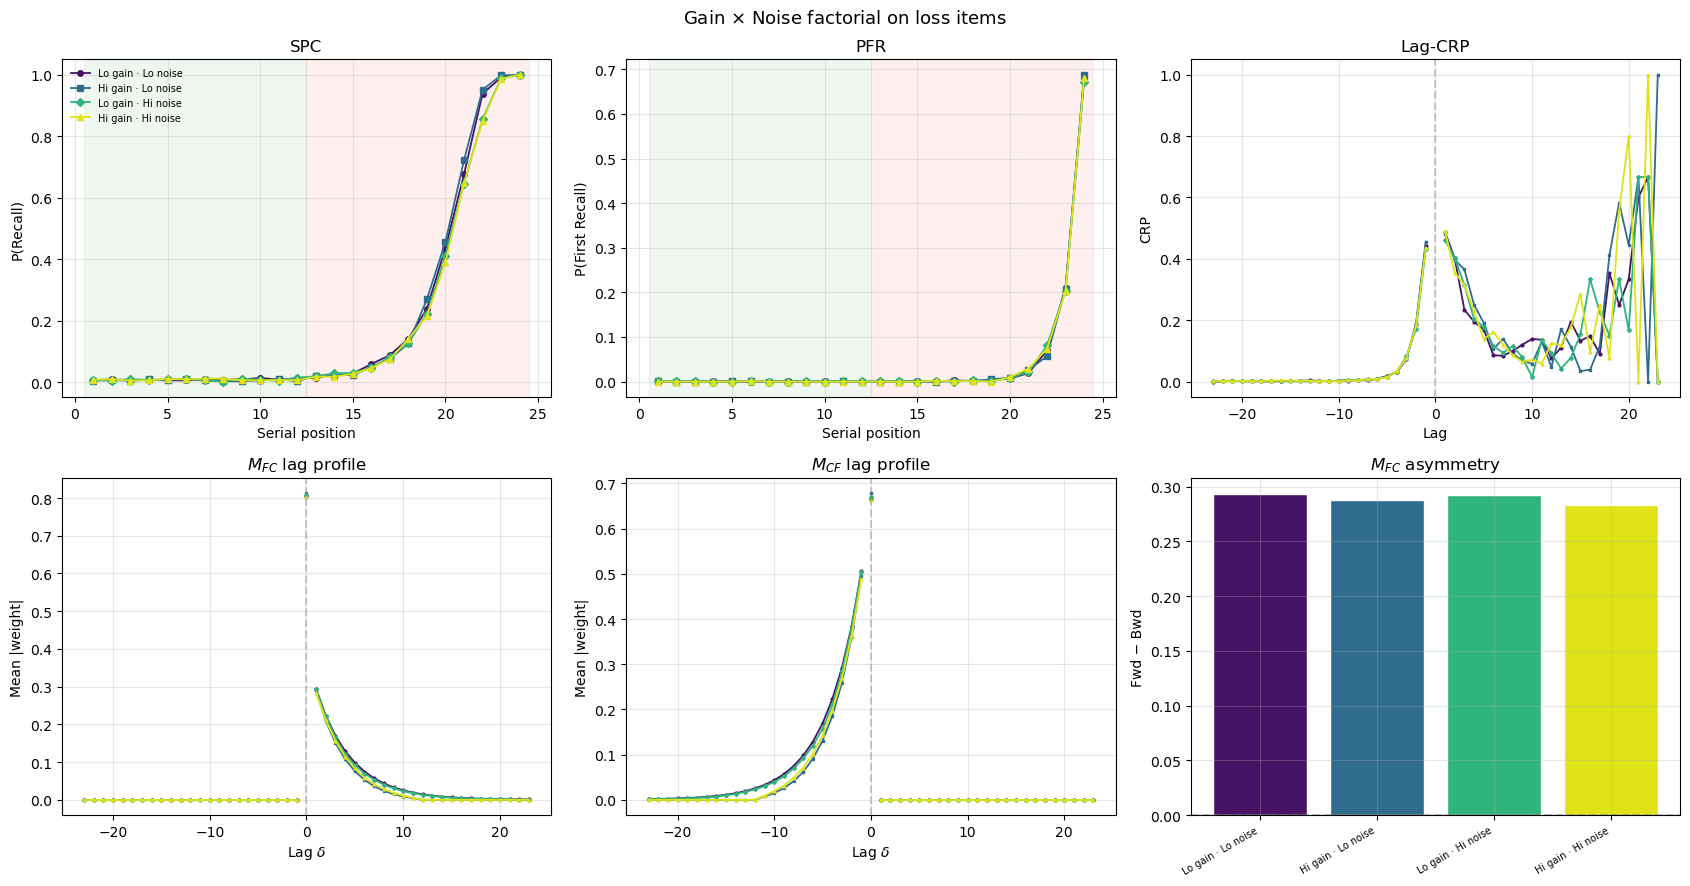

In [40]:
fig, axs = plt.subplots(2, 3, figsize=(17, 9))

for (name, _, _), c, mk in zip(factorial_conds, fact_colors, fact_markers):
    rs = fact_results[name]['recall_sims']

    axs[0,0].plot(positions, compute_spc(rs, N),
                  marker=mk, color=c, lw=1.3, ms=4, label=name)
    axs[0,1].plot(positions, compute_pfr(rs, N),
                  marker=mk, color=c, lw=1.3, ms=4)

    lags, crp = compute_lag_crp(rs, N)
    for m in [lags < 0, lags > 0]:
        axs[0,2].plot(lags[m], crp[m], marker=mk, color=c, lw=1.3, ms=2)

    W_fc = remap_to_serial_position_space(fact_results[name]['net_w_fc'])
    l1, p1 = lag_strength_profile(W_fc)
    for m in [l1 < 0, l1 == 0, l1 > 0]:
        axs[1,0].plot(l1[m], p1[m], marker=mk, color=c, lw=1.3, ms=2)

    W_cf = remap_to_serial_position_space(fact_results[name]['net_w_cf'])
    l2, p2 = lag_strength_profile(W_cf)
    for m in [l2 < 0, l2 == 0, l2 > 0]:
        axs[1,1].plot(l2[m], p2[m], marker=mk, color=c, lw=1.3, ms=2)

# Asymmetry bars
names_f = [c[0] for c in factorial_conds]
asym_list = []
for name in names_f:
    W_sp = remap_to_serial_position_space(fact_results[name]['net_w_fc'])
    _, _, a = compute_forward_backward_asymmetry(W_sp)
    asym_list.append(a)
axs[1,2].bar(np.arange(4), asym_list, color=fact_colors, edgecolor='white')
axs[1,2].axhline(0, ls='--', color='gray', alpha=0.5)
axs[1,2].set_xticks(np.arange(4))
axs[1,2].set_xticklabels(names_f, rotation=30, ha='right', fontsize=7)

axs[0,0].set(xlabel='Serial position', ylabel='P(Recall)', title='SPC')
axs[0,1].set(xlabel='Serial position', ylabel='P(First Recall)', title='PFR')
axs[0,2].set(xlabel='Lag', ylabel='CRP', title='Lag-CRP')
axs[0,2].axvline(0, color='gray', ls='--', alpha=0.4)
axs[1,0].set(xlabel=r'Lag $\delta$', ylabel='Mean |weight|', title=r'$M_{FC}$ lag profile')
axs[1,0].axvline(0, color='gray', ls='--', alpha=0.4)
axs[1,1].set(xlabel=r'Lag $\delta$', ylabel='Mean |weight|', title=r'$M_{CF}$ lag profile')
axs[1,1].axvline(0, color='gray', ls='--', alpha=0.4)
axs[1,2].set(ylabel='Fwd − Bwd', title=r'$M_{FC}$ asymmetry')

for ax in [axs[0,0], axs[0,1]]:
    ax.axvspan(0.5, 12.5, alpha=0.06, color='green')
    ax.axvspan(12.5, 24.5, alpha=0.06, color='red')
for ax in axs.flat: ax.grid(alpha=0.3)
axs[0,0].legend(frameon=False, fontsize=7)

fig.suptitle(r'Gain $\times$ Noise factorial on loss items', fontsize=13)
fig.tight_layout(); plt.show()

---
# Part 2 — Tonic $\beta_{enc}$ Decrease on Reward Items

### Hypothesis

PTSD-related anhedonia manifests as a **pessimistic prior** that
tonically reduces context drift during reward-context encoding
(Nawijn et al., 2015).  This is modelled by multiplying
$\beta_{enc}$ at reward positions by a scale factor $s < 1$:

$$\beta_{enc}^{\text{reward}}[i] = s \times \beta_{enc}^{\text{base}}[i]
\qquad \text{(reward positions only)}$$

We test three levels: $s \in \{1.0, \; 0.85, \; 0.70\}$.

## Build tonic reward conditions

In [41]:
reward_scales = [1.0, 0.85, 0.70]
reward_conds = []
for s in reward_scales:
    B = apply_reward_tonic_scale(B_encD_baseline, scale=s,
                                reward_mask=REWARD_POSITIONS)
    label = f's = {s:.2f}'
    reward_conds.append((label, B, s))
    print(f'  {label}: {np.round(B, 3)}')

  s = 1.00: [1.   0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65
 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65 0.65]
  s = 0.85: [0.85  0.552 0.552 0.552 0.552 0.552 0.552 0.552 0.552 0.552 0.552 0.552
 0.65  0.65  0.65  0.65  0.65  0.65  0.65  0.65  0.65  0.65  0.65  0.65 ]
  s = 0.70: [0.7   0.455 0.455 0.455 0.455 0.455 0.455 0.455 0.455 0.455 0.455 0.455
 0.65  0.65  0.65  0.65  0.65  0.65  0.65  0.65  0.65  0.65  0.65  0.65 ]


### Visualize reward-scaled drift

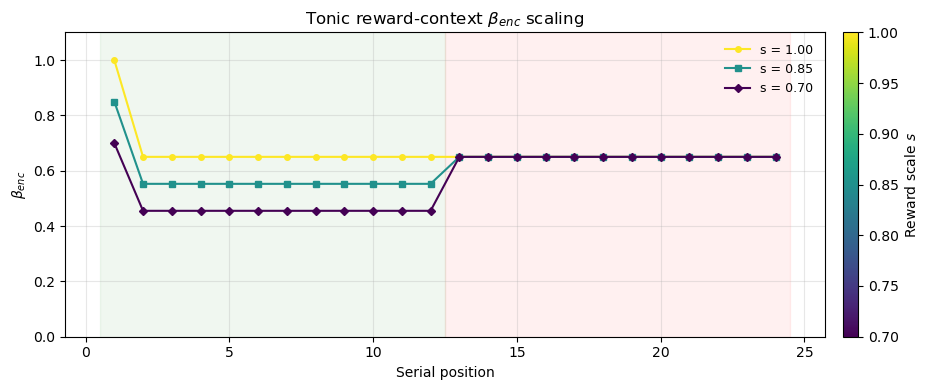

In [42]:
cmap_r = plt.get_cmap('viridis')
norm_r = mpl.colors.Normalize(vmin=min(reward_scales), vmax=max(reward_scales))
reward_colors = [cmap_r(norm_r(s)) for s in reward_scales]
reward_markers = ['o', 's', 'D']

fig, ax = plt.subplots(figsize=(10, 4))
for (label, B, s), c, m in zip(reward_conds, reward_colors, reward_markers):
    ax.plot(positions, B, marker=m, color=c, lw=1.5, ms=4, label=label)
ax.axvspan(0.5, 12.5, alpha=0.06, color='green')
ax.axvspan(12.5, 24.5, alpha=0.06, color='red')
ax.set_xlabel('Serial position')
ax.set_ylabel(r'$\beta_{enc}$')
ax.set_title(r'Tonic reward-context $\beta_{enc}$ scaling')
ax.set_ylim(0, 1.1)
ax.legend(frameon=False, fontsize=9); ax.grid(alpha=0.3)

# colourbar
sm = mpl.cm.ScalarMappable(norm=norm_r, cmap=cmap_r); sm.set_array([])
fig.colorbar(sm, ax=ax, pad=0.02, label='Reward scale $s$')
fig.tight_layout(); plt.show()

## Run tonic reward simulations

In [43]:
reward_results = {}
for (label, B, s), c in zip(reward_conds, reward_colors):
    print(f'  {label:12s} ...', end=' ')
    reward_results[label] = run_batch(
        B_encD_base=B,
        n_sims=N_SIMS,
        seed=SEED,
        drift_noise_std=0.0,   # no noise — deterministic
        noise_mask=None,
        label=label,
    )
    acc = recall_accuracy(reward_results[label]['recall_sims'], N)
    print(f'done  (accuracy = {acc:.3f})')

  s = 1.00     ... done  (accuracy = 0.198)
  s = 0.85     ... done  (accuracy = 0.200)
  s = 0.70     ... done  (accuracy = 0.200)


## Tonic reward — Behavioral metrics

### Serial Position Curve

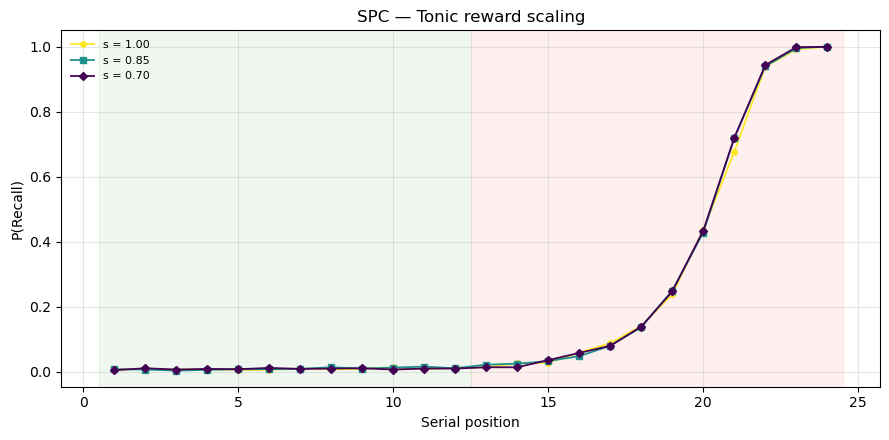

In [44]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for (label, _, s), c, m in zip(reward_conds, reward_colors, reward_markers):
    spc = compute_spc(reward_results[label]['recall_sims'], N)
    ax.plot(positions, spc, marker=m, color=c, label=label, lw=1.3, ms=4)
ax.axvspan(0.5, 12.5, alpha=0.06, color='green')
ax.axvspan(12.5, 24.5, alpha=0.06, color='red')
ax.set_xlabel('Serial position'); ax.set_ylabel('P(Recall)')
ax.set_title('SPC — Tonic reward scaling')
ax.legend(frameon=False, fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

### Probability of First Recall

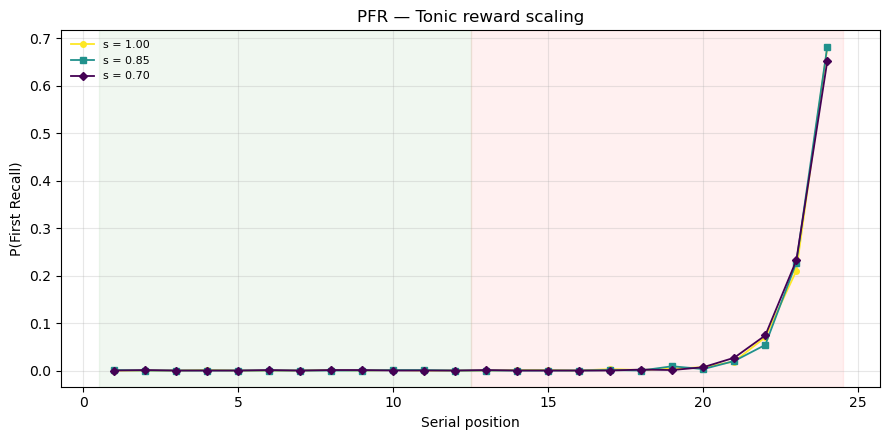

In [45]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for (label, _, s), c, m in zip(reward_conds, reward_colors, reward_markers):
    pfr = compute_pfr(reward_results[label]['recall_sims'], N)
    ax.plot(positions, pfr, marker=m, color=c, label=label, lw=1.3, ms=4)
ax.axvspan(0.5, 12.5, alpha=0.06, color='green')
ax.axvspan(12.5, 24.5, alpha=0.06, color='red')
ax.set_xlabel('Serial position'); ax.set_ylabel('P(First Recall)')
ax.set_title('PFR — Tonic reward scaling')
ax.legend(frameon=False, fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

### Lag-CRP

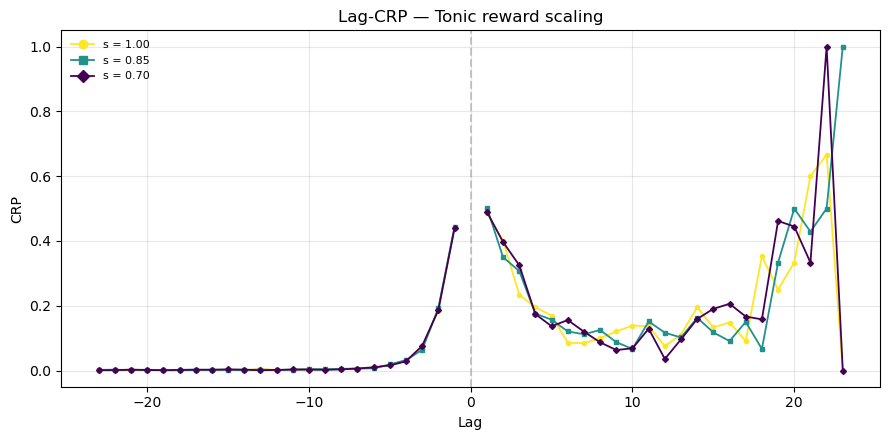

In [46]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for (label, _, s), c, m in zip(reward_conds, reward_colors, reward_markers):
    lags, crp = compute_lag_crp(reward_results[label]['recall_sims'], N)
    for mask in [lags < 0, lags > 0]:
        ax.plot(lags[mask], crp[mask], marker=m, color=c, lw=1.3, ms=3)
ax.axvline(0, color='gray', ls='--', alpha=0.4)
ax.set_xlabel('Lag'); ax.set_ylabel('CRP')
ax.set_title('Lag-CRP — Tonic reward scaling')
handles = [plt.Line2D([],[], marker=reward_markers[i], color=reward_colors[i],
           lw=1.3, label=reward_conds[i][0]) for i in range(3)]
ax.legend(handles=handles, frameon=False, fontsize=8)
ax.grid(alpha=0.3); fig.tight_layout(); plt.show()

### Recall accuracy

In [47]:
print(f"{'Condition':<15s}  {'Accuracy':>8s}")
print('-' * 27)
for label in reward_results:
    acc = recall_accuracy(reward_results[label]['recall_sims'], N)
    print(f'{label:<15s}  {acc:8.3f}')

Condition        Accuracy
---------------------------
s = 1.00            0.198
s = 0.85            0.200
s = 0.70            0.200


## Tonic reward — Encoding matrix diagnostics

### $M_{FC}$ lag-strength profile

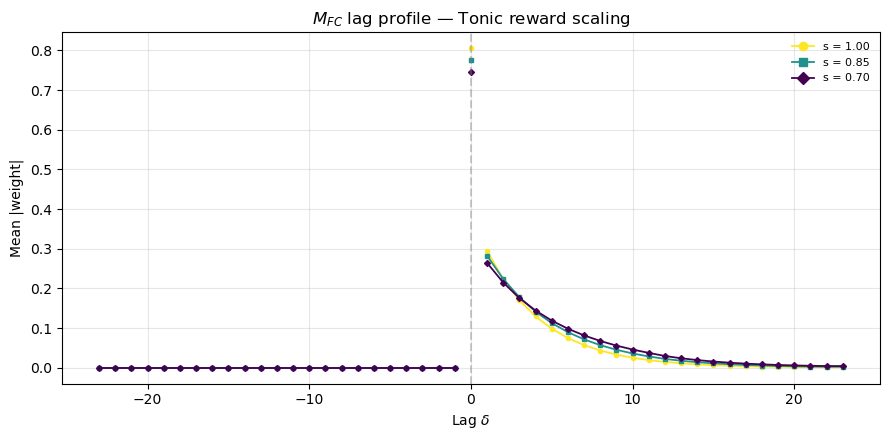

In [48]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for (label, _, s), c, m in zip(reward_conds, reward_colors, reward_markers):
    W_sp = remap_to_serial_position_space(reward_results[label]['net_w_fc'])
    lags, prof = lag_strength_profile(W_sp)
    for mask in [lags < 0, lags == 0, lags > 0]:
        ax.plot(lags[mask], prof[mask], marker=m, color=c, lw=1.3, ms=3)
ax.axvline(0, color='gray', ls='--', alpha=0.4)
ax.set_xlabel(r'Lag $\delta$'); ax.set_ylabel('Mean |weight|')
ax.set_title(r'$M_{FC}$ lag profile — Tonic reward scaling')
handles = [plt.Line2D([],[], marker=reward_markers[i], color=reward_colors[i],
           lw=1.3, label=reward_conds[i][0]) for i in range(3)]
ax.legend(handles=handles, frameon=False, fontsize=8)
ax.grid(alpha=0.3); fig.tight_layout(); plt.show()

## Tonic reward — Compact panel

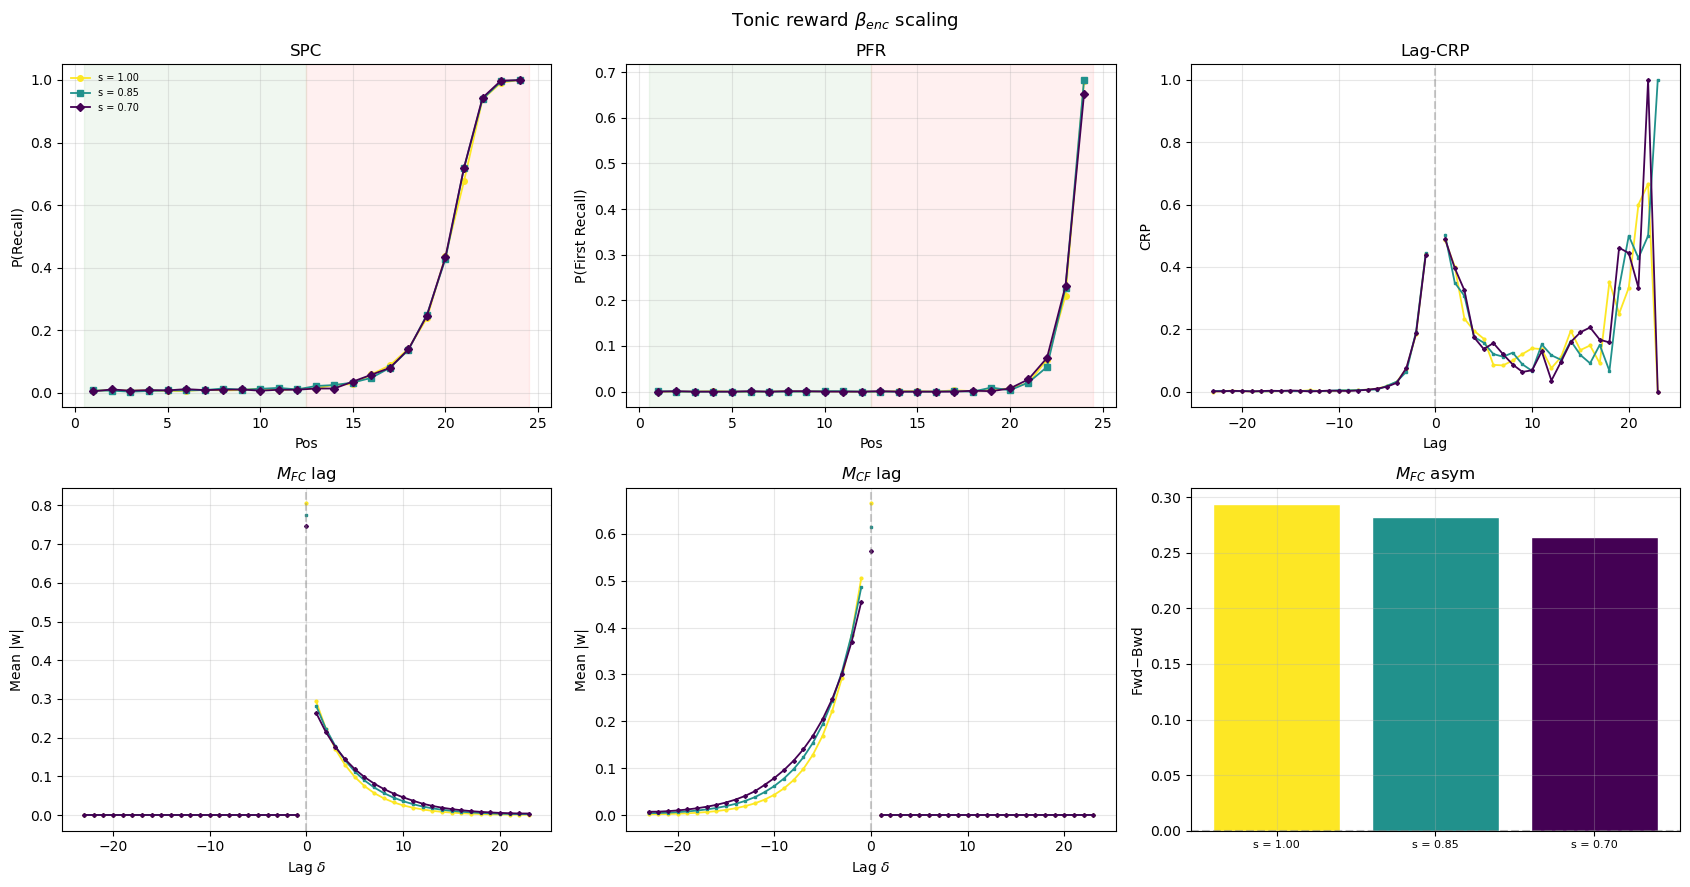

In [49]:
fig, axs = plt.subplots(2, 3, figsize=(17, 9))

for (label, _, s), c, mk in zip(reward_conds, reward_colors, reward_markers):
    rs = reward_results[label]['recall_sims']

    axs[0,0].plot(positions, compute_spc(rs, N),
                  marker=mk, color=c, lw=1.3, ms=4, label=label)
    axs[0,1].plot(positions, compute_pfr(rs, N),
                  marker=mk, color=c, lw=1.3, ms=4)
    lags, crp = compute_lag_crp(rs, N)
    for m in [lags < 0, lags > 0]:
        axs[0,2].plot(lags[m], crp[m], marker=mk, color=c, lw=1.3, ms=2)

    W_fc = remap_to_serial_position_space(reward_results[label]['net_w_fc'])
    l1, p1 = lag_strength_profile(W_fc)
    for m in [l1 < 0, l1 == 0, l1 > 0]:
        axs[1,0].plot(l1[m], p1[m], marker=mk, color=c, lw=1.3, ms=2)

    W_cf = remap_to_serial_position_space(reward_results[label]['net_w_cf'])
    l2, p2 = lag_strength_profile(W_cf)
    for m in [l2 < 0, l2 == 0, l2 > 0]:
        axs[1,1].plot(l2[m], p2[m], marker=mk, color=c, lw=1.3, ms=2)

# asymmetry bars
asym_r = []
for (label, _, s) in reward_conds:
    W_sp = remap_to_serial_position_space(reward_results[label]['net_w_fc'])
    _, _, a = compute_forward_backward_asymmetry(W_sp)
    asym_r.append(a)
axs[1,2].bar(np.arange(3), asym_r, color=reward_colors, edgecolor='white')
axs[1,2].axhline(0, ls='--', color='gray', alpha=0.5)
axs[1,2].set_xticks(np.arange(3))
axs[1,2].set_xticklabels([c[0] for c in reward_conds], fontsize=8)

axs[0,0].set(xlabel='Pos', ylabel='P(Recall)', title='SPC')
axs[0,1].set(xlabel='Pos', ylabel='P(First Recall)', title='PFR')
axs[0,2].set(xlabel='Lag', ylabel='CRP', title='Lag-CRP')
axs[0,2].axvline(0, color='gray', ls='--', alpha=0.4)
axs[1,0].set(xlabel=r'Lag $\delta$', ylabel='Mean |w|', title=r'$M_{FC}$ lag')
axs[1,0].axvline(0, color='gray', ls='--', alpha=0.4)
axs[1,1].set(xlabel=r'Lag $\delta$', ylabel='Mean |w|', title=r'$M_{CF}$ lag')
axs[1,1].axvline(0, color='gray', ls='--', alpha=0.4)
axs[1,2].set(ylabel='Fwd−Bwd', title=r'$M_{FC}$ asym')

for ax in [axs[0,0], axs[0,1]]:
    ax.axvspan(0.5, 12.5, alpha=0.06, color='green')
    ax.axvspan(12.5, 24.5, alpha=0.06, color='red')
for ax in axs.flat: ax.grid(alpha=0.3)
axs[0,0].legend(frameon=False, fontsize=7)

fig.suptitle(r'Tonic reward $\beta_{enc}$ scaling', fontsize=13)
fig.tight_layout(); plt.show()

---
## Noise verification

Violin plots of actual per-trial $\beta_{enc}$ values for the two
noisy factorial conditions, confirming that noise is injected
only at loss positions (13–24) and that reward positions (1–12)
are unperturbed.

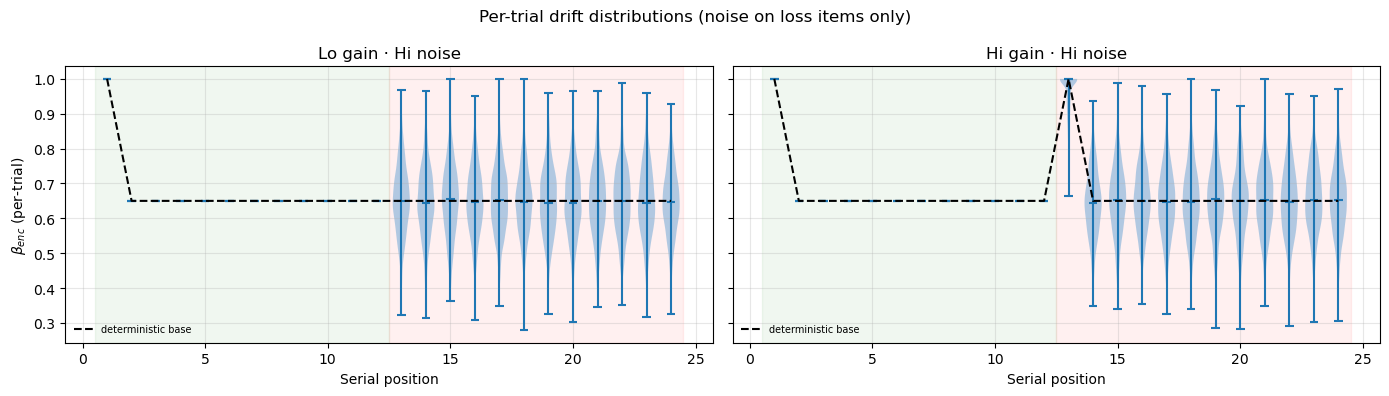

In [50]:
noisy_labels = ['Lo gain · Hi noise', 'Hi gain · Hi noise']

fig, axs = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, label in zip(axs, noisy_labels):
    B_trials = fact_results[label]['B_encD_trials']
    parts = ax.violinplot(
        [B_trials[:, i] for i in range(N)],
        positions=positions, showmedians=True, widths=0.7,
    )
    for pc in parts['bodies']:
        pc.set_facecolor('#3498db'); pc.set_alpha(0.4)
    ax.plot(positions, fact_results[label]['B_encD_base'],
            'k--', lw=1.5, label='deterministic base')
    ax.axvspan(0.5, 12.5, alpha=0.06, color='green')
    ax.axvspan(12.5, 24.5, alpha=0.06, color='red')
    ax.set_xlabel('Serial position'); ax.set_title(label)
    ax.legend(frameon=False, fontsize=7); ax.grid(alpha=0.3)
axs[0].set_ylabel(r'$\beta_{enc}$ (per-trial)')
fig.suptitle('Per-trial drift distributions (noise on loss items only)', fontsize=12)
fig.tight_layout(); plt.show()

---
## Summary

### Part 1 — Gain × Noise on loss items

| Readout | ↑ Gain | ↑ Noise | Both |
|---|---|---|---|
| SPC | Altered loss-item recall | Flatter loss-item recall | Combined |
| PFR | Shift toward high-RPE positions | More diffuse | Mixed |
| Lag-CRP | Sharper contiguity near RPE spike | Washed-out contiguity | Partial cancellation |
| $M_{FC}$ profile | Higher peak near loss boundary | Less peaked | Depends on magnitudes |

### Part 2 — Tonic reward bias

| Readout | $s = 0.85$ | $s = 0.70$ |
|---|---|---|
| SPC | Mild reward-block recall decrease | Stronger decrease |
| PFR | Reduced reward-block first recalls | Pronounced shift |
| Lag-CRP | Weakened contiguity | Further weakened |
| $M_{FC}$ profile | Slightly reduced weights | Substantially reduced |

### Key citations

- **Brown et al. (2018)** — ↑ associability-modulated loss learning → ↑ trial-wise $\beta_{enc}$ spikes
- **Pitts et al. (2022); Granger et al. (2025)** — noisier PE → drift modulation
- **Ross & Cisler (2018); Letkiewicz et al. (2023)** — blunted PE encoding → ↓ drift modulation
- **Nawijn et al. (2015)** — tonic ↓ reward expectation → ↓ reward-context drift
- **Letkiewicz, Cochran & Cisler (2022)** — reduced latent-state updates → ↓ boundary drift